In [1]:
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import itertools
import numpy as np
from tqdm.notebook import tqdm

In [2]:
df = pd.read_csv('part1/data/nav.trn', sep='\t', header=None, names=["root", "content", "form"])
df

,root,content,form
0,achįʼ,"V;IND;IPFV;NOM(1,GRPL)",daʼiichįʼ
1,achįʼ,"V;IND;IPFV;NOM(1,PL)",iichįʼ
2,achįʼ,"V;IND;IPFV;NOM(1,SG)",ashchįʼ
3,achįʼ,"V;IND;IPFV;NOM(2,GRPL)",daʼohchįʼ
4,achįʼ,"V;IND;IPFV;NOM(2,PL)",ohchįʼ
...,...,...,...
9995,łíícháázh,"V;IND;PFV;NOM(3,PL)",łííshcháázh
9996,łíícháázh,"V;IND;PFV;NOM(3,SG)",łííshcháázh
9997,łíícháázh,"V;IND;PFV;NOM(4,GRPL)",łídajishcháázh
9998,łíícháázh,"V;IND;PFV;NOM(4,PL)",łíjíshcháázh


In [3]:
data = []
for root in df.root.unique():
    data.append({
        "root": root,
        "content": "ROOT",
        "form": root,
    })
root_df = pd.DataFrame(data=data)
df = pd.concat([df, root_df], ignore_index=True)
df[df.root == df.form]

,root,content,form
7,achįʼ,"V;IND;IPFV;NOM(3,PL)",achįʼ
8,achįʼ,"V;IND;IPFV;NOM(3,SG)",achįʼ
31,achʼiish,"V;IND;IPFV;NOM(3,PL)",achʼiish
32,achʼiish,"V;IND;IPFV;NOM(3,SG)",achʼiish
55,adiłhash,"V;IND;PFV;NOM(3,PL)",adiłhash
...,...,...,...
10389,óolyé,ROOT,óolyé
10390,łichxííʼ,ROOT,łichxííʼ
10391,łikizh,ROOT,łikizh
10392,łikʼaii,ROOT,łikʼaii


In [4]:
%%time
onegram_vocab = set()
for row in df.itertuples():
    onegram_vocab |= set(row.content)
    onegram_vocab |= set(row.form)
GLOSS_START, GLOSS_END = "GLOSS_START", "GLOSS_END"
onegram_vocab |= set((GLOSS_START, GLOSS_END, "PAD"))

onegram_vocab = dict((w, i) for (i, w) in enumerate(onegram_vocab))

def get_sequence(word):
    idxs = [onegram_vocab[c] for c in word]
    idxs = [onegram_vocab[GLOSS_START]] + idxs + [onegram_vocab[GLOSS_END]]
    return torch.stack([torch.Tensor([int(i == j) for i in range(len(onegram_vocab))]) for j in idxs])
    
df['content_sequence'] = df.content.apply(get_sequence)
df['form_sequence'] = df.form.apply(get_sequence)
df

CPU times: total: 28 s
Wall time: 31.1 s


,root,content,form,content_sequence,form_sequence
0,achįʼ,"V;IND;IPFV;NOM(1,GRPL)",daʼiichįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
1,achįʼ,"V;IND;IPFV;NOM(1,PL)",iichįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
2,achįʼ,"V;IND;IPFV;NOM(1,SG)",ashchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
3,achįʼ,"V;IND;IPFV;NOM(2,GRPL)",daʼohchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
4,achįʼ,"V;IND;IPFV;NOM(2,PL)",ohchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
...,...,...,...,...,...
10389,óolyé,ROOT,óolyé,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
10390,łichxííʼ,ROOT,łichxííʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
10391,łikizh,ROOT,łikizh,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
10392,łikʼaii,ROOT,łikʼaii,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."


In [5]:
%%time
test_df = pd.read_csv('part1/data/nav.tst', sep='\t', header=None, names=["root", "content", "form"])

data = []
for root in test_df.root.unique():
    data.append({
        "root": root,
        "content": "ROOT",
        "form": root,
    })
root_df = pd.DataFrame(data=data)
test_df = pd.concat([test_df, root_df], ignore_index=True)

test_df['content_sequence'] = test_df.content.apply(get_sequence)
test_df['form_sequence'] = test_df.form.apply(get_sequence)
test_df

CPU times: total: 2.88 s
Wall time: 3.1 s


,root,content,form,content_sequence,form_sequence
0,adiníłdíín,"V;IND;PFV;NOM(1,GRPL)",daʼdííníildíín,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
1,adiníłdíín,"V;IND;PFV;NOM(1,PL)",adííníildíín,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
2,adiníłdíín,"V;IND;PFV;NOM(1,SG)",adííníshdíín,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
3,adiníłdíín,"V;IND;PFV;NOM(2,GRPL)",daʼdíínółdíín,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
4,adiníłdíín,"V;IND;PFV;NOM(2,PL)",adíínółdíín,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
...,...,...,...,...,...
1045,yoołbąs,ROOT,yoołbąs,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
1046,yoołtʼah,ROOT,yoołtʼah,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
1047,yólgę́ę́zh,ROOT,yólgę́ę́zh,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
1048,łitsxo,ROOT,łitsxo,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."


In [6]:
onegram_vocab

{'T': 0,
 'N': 1,
 'd': 2,
 'e': 3,
 'k': 4,
 'b': 5,
 ';': 6,
 'O': 7,
 'o': 8,
 'm': 9,
 'F': 10,
 'á': 11,
 'S': 12,
 'G': 13,
 'I': 14,
 '1': 15,
 'V': 16,
 'L': 17,
 ' ': 18,
 'ę': 19,
 'į': 20,
 'g': 21,
 'M': 22,
 'D': 23,
 'c': 24,
 '2': 25,
 '3': 26,
 'GLOSS_END': 27,
 '4': 28,
 's': 29,
 'ł': 30,
 'a': 31,
 ',': 32,
 'l': 33,
 'i': 34,
 'z': 35,
 'x': 36,
 'n': 37,
 'é': 38,
 'y': 39,
 't': 40,
 'PAD': 41,
 'ą': 42,
 '(': 43,
 'í': 44,
 'ǫ': 45,
 'E': 46,
 'ń': 47,
 'w': 48,
 'GLOSS_START': 49,
 'ó': 50,
 'j': 51,
 '́': 52,
 'ʼ': 53,
 'P': 54,
 'R': 55,
 'h': 56,
 ')': 57}

In [7]:
[g
 for seq in df.iloc[2].content_sequence
 for (g, i) in onegram_vocab.items()
 if i == torch.argmax(seq).item()]

['GLOSS_START',
 'V',
 ';',
 'I',
 'N',
 'D',
 ';',
 'I',
 'P',
 'F',
 'V',
 ';',
 'N',
 'O',
 'M',
 '(',
 '1',
 ',',
 'S',
 'G',
 ')',
 'GLOSS_END']

In [8]:
[g
 for seq in df.iloc[2].form_sequence
 for (g, i) in onegram_vocab.items()
 if i == torch.argmax(seq).item()]

['GLOSS_START', 'a', 's', 'h', 'c', 'h', 'į', 'ʼ', 'GLOSS_END']

In [9]:
class MyModel(torch.nn.Module):

    def __init__(self, d_input, num_glosses):
        super().__init__()
        self.conv1 = torch.nn.Conv1d(
            in_channels=d_input,
            out_channels=256,
            kernel_size=3,
            padding='same',
        )
        self.conv2 = torch.nn.Conv1d(
            in_channels=256,
            out_channels=num_glosses,
            kernel_size=3,
            padding='same',
        )
        self.transformer = nn.Transformer(
            d_model=num_glosses,
            nhead=2,
            num_encoder_layers=1,
            num_decoder_layers=1,
            #dim_feedforward=64,
        )
        self.log_softmax = nn.LogSoftmax(dim=-1)

        max_len = 50
        pos_encoding = torch.zeros(max_len, num_glosses, requires_grad=False)
        positions_list = torch.arange(0, max_len, dtype=torch.float).view(-1, 1)
        division_term = torch.exp(torch.arange(0, num_glosses, 2).float() * (-math.log(10000.0)) / num_glosses)
        pos_encoding[:, 0::2] = torch.sin(positions_list * division_term)
        pos_encoding[:, 1::2] = torch.cos(positions_list * division_term)
        self.register_buffer('pos_encoding', pos_encoding)

    def forward(self, X, y, tgt_mask=None, tgt_is_causal=False):
        X = torch.permute(X.unsqueeze(0), dims=(0, 2, 1)) # To N, C, L
        X = self.conv1(X)
        X = self.conv2(X)
        X = torch.permute(X.squeeze(), dims=(1, 0)) # Back to L, C
        X += self.pos_encoding[:X.shape[0], :X.shape[1]]
        transformer_out = self.transformer(X, y, tgt_mask=tgt_mask, tgt_is_causal=tgt_is_causal)
        out = self.log_softmax(transformer_out)
        return out

d_model = len(onegram_vocab)
print(f"d_model={d_model}")
form_model = MyModel(d_model*3, d_model)
content_model = MyModel(d_model*3, d_model)

num_params = sum(p.numel() for p in form_model.parameters() if p.requires_grad)
num_params += sum(p.numel() for p in content_model.parameters() if p.requires_grad)
print(f"Num params={num_params}")

criterion = nn.NLLLoss(reduction='sum')
optimizer = torch.optim.Adam(itertools.chain(form_model.parameters(), content_model.parameters()), lr=1e-4)
losses = []

d_model=58
Num params=1399428


C:\Users\Mike\anaconda3\envs\conjugations\Lib\site-packages\torch\nn\modules\transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.encoder = TransformerEncoder(


In [10]:
def get_random_pair(row, source_df):
    root = row.root
    mask = source_df.root == root
    return source_df[mask].sample(n=1).iloc[0]
    
df.head().apply(lambda row: get_random_pair(row, df), axis=1, result_type='expand')

,root,content,form,content_sequence,form_sequence
0,achįʼ,"V;IND;IPFV;NOM(2,SG)",íchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
1,achįʼ,"V;IND;PFV;NOM(4,SG)",ajizhchąąʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
2,achįʼ,"V;IND;IPFV;NOM(3,PL)",achįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
3,achįʼ,"V;IND;IPFV;NOM(1,PL)",iichįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."
4,achįʼ,"V;IND;IPFV;NOM(1,PL)",iichįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0..."


In [11]:
pad_vector = torch.Tensor([int(i == onegram_vocab['PAD']) for i in range(len(onegram_vocab))])
pad_vector = pad_vector.unsqueeze(0)
print(pad_vector.shape)

start_vector = torch.Tensor([int(i == onegram_vocab[GLOSS_START]) for i in range(len(onegram_vocab))])
start_vector = start_vector.unsqueeze(0)

def train_step(form_model, content_model, train_df, num_examples=1, num_epochs=1):
    losses = []
    form_model.train()
    content_model.train()
    pbar = tqdm(total=num_examples * num_epochs)
    for n in range(num_epochs):
        epoch_loss = 0
        for row in train_df.sample(n=num_examples).itertuples():
            pair = get_random_pair(row, train_df)
            
            # First content prediction
            seqs = (row.form_sequence, row.content_sequence, pair.form_sequence)
            maxlen = max(s.shape[0] for s in seqs)
            vs = []
            for s in seqs:
                while s.shape[0] < maxlen:
                    s = torch.cat((s, pad_vector), dim=0)
                vs.append(s)
            X = torch.cat(vs, dim=1)
            y = pair.content_sequence[:-1, :]
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(y.shape[0])
            pred_content = content_model(X, y, tgt_mask=tgt_mask, tgt_is_causal=True)
            actual_content = torch.argmax(pair.content_sequence[1:], axis=1)
            loss = criterion(pred_content, actual_content)

            # First form prediction
            seqs = (row.form_sequence, row.content_sequence, torch.cat((start_vector, pred_content)))
            maxlen = max(s.shape[0] for s in seqs)
            vs = []
            for s in seqs:
                while s.shape[0] < maxlen:
                    s = torch.cat((s, pad_vector), dim=0)
                vs.append(s)
            X = torch.cat(vs, dim=1)
            y = pair.form_sequence[:-1, :]
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(y.shape[0])
            pred_form = form_model(X, y, tgt_mask=tgt_mask, tgt_is_causal=True)
            actual_form = torch.argmax(pair.form_sequence[1:], axis=1)
            loss += criterion(pred_form, actual_form)

            # Second content prediction
            seqs = (torch.cat((start_vector, pred_form)), pair.content_sequence, row.form_sequence)
            maxlen = max(s.shape[0] for s in seqs)
            vs = []
            for s in seqs:
                while s.shape[0] < maxlen:
                    s = torch.cat((s, pad_vector), dim=0)
                vs.append(s)
            X = torch.cat(vs, dim=1)
            y = row.content_sequence[:-1, :]
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(y.shape[0])
            pred_content = content_model(X, y, tgt_mask=tgt_mask, tgt_is_causal=True)
            actual_content = torch.argmax(row.content_sequence[1:], axis=1)
            loss += criterion(pred_content, actual_content)

            # Second form prediction
            seqs = (pair.form_sequence, pair.content_sequence, torch.cat((start_vector, pred_content)))
            maxlen = max(s.shape[0] for s in seqs)
            vs = []
            for s in seqs:
                while s.shape[0] < maxlen:
                    s = torch.cat((s, pad_vector), dim=0)
                vs.append(s)
            X = torch.cat(vs, dim=1)
            y = row.form_sequence[:-1, :]
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(y.shape[0])
            pred_form = form_model(X, y, tgt_mask=tgt_mask, tgt_is_causal=True)
            actual_form = torch.argmax(row.form_sequence[1:], axis=1)
            loss += criterion(pred_form, actual_form)

            epoch_loss += loss.detach().item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            pbar.update(1)
        losses.append(epoch_loss / num_examples)
    return losses

torch.Size([1, 58])


In [65]:
losses += train_step(form_model, content_model, df, num_examples=10000, num_epochs=4 * 8)

  0%|          | 0/320000 [00:00<?, ?it/s]

<Axes: >

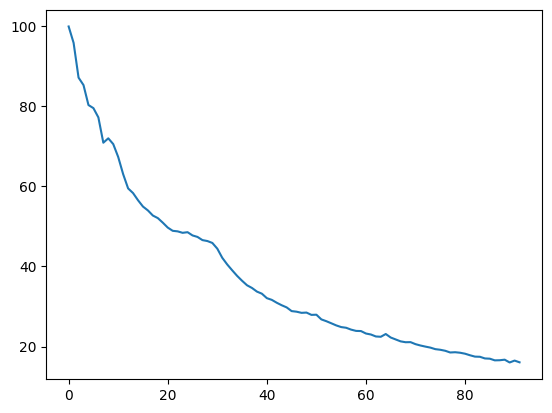

In [66]:
pd.Series(losses).plot(logy=False)

<Axes: >

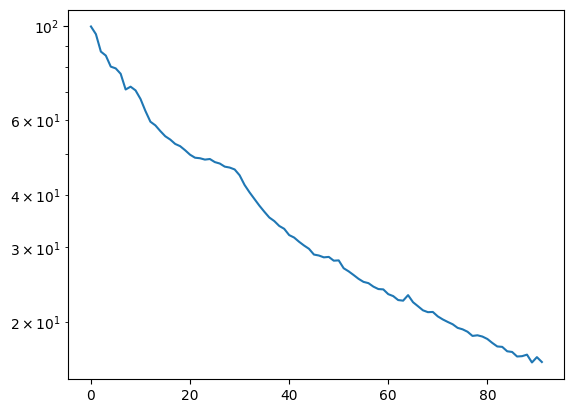

In [67]:
pd.Series(losses).plot(logy=True)

In [68]:
def eval_inflection(form_model, row, eval_df):
    form_model.eval()
    seqs = (get_sequence(row.root), get_sequence("ROOT"), row.content_sequence)
    maxlen = max(s.shape[0] for s in seqs)
    vs = []
    for s in seqs:
        while s.shape[0] < maxlen:
            s = torch.cat((s, pad_vector), dim=0)
        vs.append(s)
    X = torch.cat(vs, dim=1)
    y = torch.zeros((1, len(onegram_vocab)))
    y[0, onegram_vocab['GLOSS_START']] = 1
    while True:
        pred = form_model(X, y)
        next_y_label = torch.argmax(pred[-1, :])
        next_y = torch.zeros((1, y.shape[1]))
        next_y[0, next_y_label] = 1
        y = torch.concat([y, next_y], axis=0)
        if torch.argmax(y[-1, :len(onegram_vocab)]) == onegram_vocab[GLOSS_END]: break
        if y.shape[0] > 100: break
    return y

n = 66
pred = eval_inflection(form_model, test_df.iloc[n], test_df)
pred = ''.join([g
 for seq in pred[1:-1]
 for (g, i) in onegram_vocab.items()
 if i == torch.argmax(seq).item()])
print(test_df.iloc[n], "\n", pred)

root                                                           hashké
content                                         V;IND;PFV;NOM(3,GRPL)
form                                                         dahashké
content_sequence    [[tensor(0.), tensor(0.), tensor(0.), tensor(0...
form_sequence       [[tensor(0.), tensor(0.), tensor(0.), tensor(0...
pred                                                         yííłdzid
Name: 66, dtype: object 
 yichaʼiish


In [69]:
n = 99
pred = eval_inflection(form_model, df.iloc[n], df)
pred = ''.join([g
 for seq in pred[1:-1]
 for (g, i) in onegram_vocab.items()
 if i == torch.argmax(seq).item()])
print(df.iloc[n], "\n", pred)

root                                                           ahigą́
content                                        V;IND;IPFV;NOM(2,GRPL)
form                                                       daʼahohgą́
content_sequence    [[tensor(0.), tensor(0.), tensor(0.), tensor(0...
form_sequence       [[tensor(0.), tensor(0.), tensor(0.), tensor(0...
pred                                                       asíníłdzíd
Name: 99, dtype: object 
 yichʼąąh


In [70]:
%%time

def decode_pred(pred):
     return ''.join([g
         for seq in pred[1:-1]
         for (g, i) in onegram_vocab.items()
         if i == torch.argmax(seq).item()])
    
test_df['pred'] = test_df.apply(lambda row: eval_inflection(form_model, row, test_df), axis=1)
test_df.pred = test_df.pred.apply(decode_pred)

accuracy = np.sum(test_df.pred == test_df.form) / test_df.shape[0]
print(f"Accuracy: {accuracy:.2%}")
test_df.loc[:, ['form', 'content', 'pred', 'root']].sample(n=20)

Accuracy: 0.00%
CPU times: total: 3min 38s
Wall time: 39.3 s


,form,content,pred,root
747,deiłhaał,"V;IND;IPFV;NOM(3,GRPL)",yichʼiiish,yiłhaał
8,adiníłdíín,"V;IND;PFV;NOM(3,SG)",yiiłniiʼ,adiníłdíín
969,łinítsxo,"V;IND;PFV;NOM(2,SG)",yiłtsóós,łitsxo
124,nisoohdzá,"V;IND;PFV;NOM(2,PL)",yiiilʼaʼ,naadá
872,diiltʼis,"V;IND;PROSP;NOM(1,PL)",yiłtʼoʼ,yiłtʼees
649,yiiltsééh,"V;IND;IPFV;NOM(1,PL)",yiłtsoos,yiyiiłtsééh
380,jinoodǫ́ǫ́z,"V;IND;PFV;NOM(4,SG)",yiłtsʼǫǫd,noodǫ́ǫ́z
672,yiiltsóóh,"V;IND;IPFV;NOM(1,PL)",yiłtsoos,yiyiiłtsóóh
293,ndadiilmas,"V;IND;PROSP;NOM(1,GRPL)",yiiłʼeeł,neiłmaas
302,ndaałtseed,"V;IND;IPFV;NOM(2,GRPL)",yiiłtsoos,neiłtseed


In [71]:
test_df[test_df.form != test_df.pred].root.value_counts()

root
hashké           25
yishood          25
yishóósh         25
yitłeeh          25
yiyiiłtsóóh      25
yiłhaał          25
yiłneʼ           25
yiłtin           25
yiłtsʼééh        25
łíidilchí        25
iizǫ́ǫ́s         24
naadá            24
naaljooł         24
naataz           24
neitłeeh         24
neiłbąąs         24
neiłgizh         24
neiłmaas         24
neiłtseed        24
neiłtʼiʼ         24
neiʼeesh         24
yichʼid          24
yidiitsʼį́į́h    24
yighááh          24
yijeeh           24
yiyiitsʼǫs       24
yiyiiłtsééh      24
yiłchʼal         24
yiłdin           24
yooznah          24
iildlóósh        23
naamaas          23
yigeeh           23
yilʼaah          23
yiłnaad          23
yiłtʼees         23
adiníłdíín       13
aheełtʼé         13
diłhił           13
diʼil            13
noodǫ́ǫ́z        13
yigoh            13
yijį́į́ł         13
yiltłʼééł        13
yootʼááł         13
yoozǫ́ǫ́s        13
yoołbąs          13
yoołtʼah         13
yólgę́ę́zh       13
łitsxo         

In [72]:
%%time
df['pred'] = df.apply(lambda row: eval_inflection(form_model, row, df), axis=1)
df.pred = df.pred.apply(decode_pred)
df

CPU times: total: 34min 17s
Wall time: 6min 8s


,root,content,form,content_sequence,form_sequence,pred
0,achįʼ,"V;IND;IPFV;NOM(1,GRPL)",daʼiichįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼąh
1,achįʼ,"V;IND;IPFV;NOM(1,PL)",iichįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼąąh
2,achįʼ,"V;IND;IPFV;NOM(1,SG)",ashchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼąh
3,achįʼ,"V;IND;IPFV;NOM(2,GRPL)",daʼohchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼąh
4,achįʼ,"V;IND;IPFV;NOM(2,PL)",ohchįʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼąąh
...,...,...,...,...,...,...
10389,óolyé,ROOT,óolyé,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yidooldził
10390,łichxííʼ,ROOT,łichxííʼ,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼiiish
10391,łikizh,ROOT,łikizh,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",chʼínísh
10392,łikʼaii,ROOT,łikʼaii,"[[tensor(0.), tensor(0.), tensor(0.), tensor(0...","[[tensor(0.), tensor(0.), tensor(0.), tensor(0...",yichʼiiish


In [73]:
accuracy = np.sum(df.pred == df.form) / df.shape[0]
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 0.11%


In [74]:
from datetime import datetime as dt
iso_time = dt.now().isoformat()
iso_time_fp = iso_time.replace(":", "_")
iso_time_fp = iso_time_fp.replace("-", "_")
PATH = f"cyclic_inflection_models.{iso_time_fp}.pt"
torch.save({
            'date': iso_time,
            'form_model_state_dict': form_model.state_dict(),
            'content_model_state_dict': form_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            }, PATH)